In [1]:
import pandas as pd
from pathlib import Path

In [2]:
DATA = Path("../data")
YEARS = [2020, 2021, 2022, 2023, 2024]

In [3]:
def load_csvs(prefix):
    files = sorted(DATA.glob(f"{prefix}-*.csv"))
    frames = []
    for file in files:
        df = pd.read_csv(file, sep=";", quotechar='"', low_memory=False)
        df["ano"] = int(file.stem.split("-")[-1]) #save year as column
        frames.append(df)
    return pd.concat(frames, ignore_index = True)

In [4]:
votacoes         = load_csvs("voting/votacoes")
votos            = load_csvs("voting/votes/votacoesVotos")
votacoes_props   = load_csvs("voting/proposition/votacoesProposicoes")
temas_propos     = load_csvs("propositions/proposicoesTemas")
orientacoes      = load_csvs("voting/orientations/votacoesOrientacoes")

In [5]:
print(votacoes.columns)
print(votos.columns)
print(votacoes_props.columns)
print(temas_propos.columns)
print(orientacoes.columns)

Index(['id', 'uri', 'data', 'dataHoraRegistro', 'idOrgao', 'uriOrgao',
       'siglaOrgao', 'idEvento', 'uriEvento', 'aprovacao', 'votosSim',
       'votosNao', 'votosOutros', 'descricao',
       'ultimaAberturaVotacao_dataHoraRegistro',
       'ultimaAberturaVotacao_descricao',
       'ultimaApresentacaoProposicao_dataHoraRegistro',
       'ultimaApresentacaoProposicao_descricao',
       'ultimaApresentacaoProposicao_idProposicao',
       'ultimaApresentacaoProposicao_uriProposicao', 'ano'],
      dtype='object')
Index(['idVotacao', 'uriVotacao', 'dataHoraVoto', 'voto', 'deputado_id',
       'deputado_uri', 'deputado_nome', 'deputado_siglaPartido',
       'deputado_uriPartido', 'deputado_siglaUf', 'deputado_idLegislatura',
       'deputado_urlFoto', 'ano'],
      dtype='object')
Index(['idVotacao', 'uriVotacao', 'data', 'descricao', 'proposicao_id',
       'proposicao_uri', 'proposicao_titulo', 'proposicao_ementa',
       'proposicao_codTipo', 'proposicao_siglaTipo', 'proposicao_numer

In [6]:
# Renoame
orientacoes = orientacoes.rename(columns={"siglaBancada": "siglaPartido", "orientacao": "orientacao_partido"})

# keep
orientacoes = orientacoes[["idVotacao", "siglaPartido", "orientacao_partido"]]

In [7]:
# Rename 'id' from votacoes to 'idVotacao'
votacoes = votacoes.rename(columns={"id": "idVotacao"})

# Merge votos + votacoes
votos_merged = votos.merge(
    votacoes[["idVotacao", "data", "descricao", "ultimaApresentacaoProposicao_idProposicao"]],
    on="idVotacao",
    how="left"
)

# Rename to keep pattern
votos_merged = votos_merged.rename(columns = {
    "ultimaApresentacaoProposicao_idProposicao":"idProposicao"
})

In [8]:
# Join dados and proposicoes
votos_merged = votos_merged.merge(
    votacoes_props[["idVotacao", "proposicao_id", "proposicao_uri"]],
    on="idVotacao",
    how="left",
    suffixes=("", "_fromPropos")
)

# Prefer the column proposicao_id from votacoesProposicoes
votos_merged["idProposicao"] = votos_merged["proposicao_id"].fillna(votos_merged["idProposicao"])
votos_merged.drop(columns=["proposicao_id"], inplace=True)

# Join with themes
votos_merged = votos_merged.merge(
    temas_propos[["uriProposicao", "tema"]],
    left_on="proposicao_uri",
    right_on="uriProposicao",
    how="left"
)

In [9]:
# Verifique os temas únicos
print(votos_merged["tema"].dropna().unique())

['Trabalho e Emprego' 'Administração Pública'
 'Direito Civil e Processual Civil' 'Estrutura Fundiária'
 'Indústria, Comércio e Serviços' 'Defesa e Segurança'
 'Previdência e Assistência Social' 'Finanças Públicas e Orçamento'
 'Direitos Humanos e Minorias' 'Economia' 'Educação'
 'Agricultura, Pecuária, Pesca e Extrativismo'
 'Processo Legislativo e Atuação Parlamentar'
 'Ciência, Tecnologia e Inovação' 'Saúde' 'Esporte e Lazer'
 'Viação, Transporte e Mobilidade'
 'Relações Internacionais e Comércio Exterior' 'Comunicações'
 'Meio Ambiente e Desenvolvimento Sustentável'
 'Cidades e Desenvolvimento Urbano'
 'Energia, Recursos Hídricos e Minerais' 'Política, Partidos e Eleições'
 'Direito e Defesa do Consumidor' 'Direito Penal e Processual Penal'
 'Arte, Cultura e Religião' 'Direito e Justiça' 'Direito Constitucional'
 'Homenagens e Datas Comemorativas' 'Turismo']


In [10]:
votos_ambientais = votos_merged[votos_merged["tema"].str.contains('Meio Ambiente e Desenvolvimento Sustentável', na=False)]

In [11]:
votos_ambientais_orientados = votos_ambientais.merge(
    orientacoes,
    left_on=["idVotacao", "deputado_siglaPartido"],
    right_on=["idVotacao", "siglaPartido"],
    how="left"
)

In [12]:
# Limpeza básica dos textos
votos_ambientais_orientados["voto"] = votos_ambientais_orientados["voto"].str.strip().str.lower()
votos_ambientais_orientados["orientacao_partido"] = votos_ambientais_orientados["orientacao_partido"].str.strip().str.lower()

# Criação do label (1 = seguiu orientação, 0 = não seguiu)
votos_ambientais_orientados["label"] = (
    votos_ambientais_orientados["voto"] == votos_ambientais_orientados["orientacao_partido"]
).astype("Int8")

In [13]:
votos_ambientais_orientados[["deputado_nome", "deputado_siglaPartido", "voto", "orientacao_partido", "label"]].sample(10)


,deputado_nome,deputado_siglaPartido,voto,orientacao_partido,label
8797,Luana Costa,PSB,não,não,1
38356,Isnaldo Bulhões Jr.,MDB,não,não,1
38751,Fernando Rodolfo,PL,sim,sim,1
69834,Rodrigo Gambale,PODE,não,NaN,0
45240,Claudio Cajado,PP,sim,sim,1
40401,David Miranda,PSOL,sim,sim,1
11035,Francisco Chapadinha,PTN,não,NaN,0
17525,Bonifácio de Andrada,DEM,não,não,1
79795,Luiz Fernando Vampiro,MDB,sim,NaN,0
34130,Mário Negromonte Jr.,PP,não,não,1


In [14]:
df_modelo = votos_ambientais_orientados.dropna(subset=["label"]).copy()

# Define a variável alvo
y = df_modelo["label"]

# Seleciona apenas colunas numéricas úteis como features
features_excluidas = [
    "label", "voto", "orientacao_partido", "deputado_nome", "proposicao_uri",
    "descricao", "tema", "voto_agostinho", "idProposicao", "deputado_urlFoto"
]
colunas_candidatas = df_modelo.select_dtypes(include=["number", "uint8", "float", "int"]).columns
X = df_modelo[[c for c in colunas_candidatas if c not in features_excluidas]]

In [15]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

clf = LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=64, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf, X, y, scoring="roc_auc", cv=cv)
print("AUROC médio (5 folds):", round(np.mean(scores), 4))


AUROC médio (5 folds): 0.8526


In [16]:
clf.fit(X, y)

LGBMClassifier(learning_rate=0.05, n_estimators=200, num_leaves=64,
               random_state=42)

In [17]:
import shap
import matplotlib.pyplot as plt

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [18]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X)  # X precisa ser o mesmo usado no .fit()

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


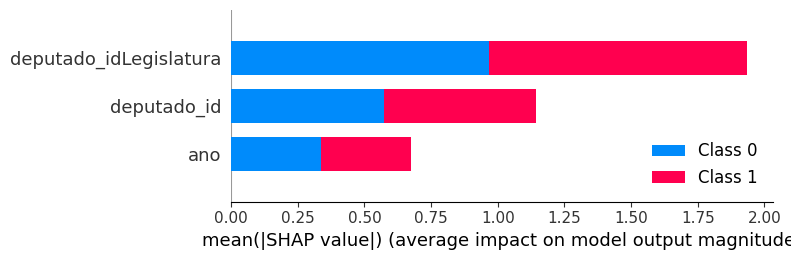

In [21]:
shap.summary_plot(shap_values, X, plot_type="bar")


In [23]:
shap_df = pd.DataFrame(shap_values[1], columns=[f"shap_{c}" for c in X.columns])

In [24]:
X_shap = pd.concat([X.reset_index(drop=True), shap_df], axis=1)

from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_shap = LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=64, random_state=42)

scores_shap = cross_val_score(clf_shap, X_shap, y, scoring="roc_auc", cv=cv)
print("AUROC com SHAP como meta-features:", round(scores_shap.mean(), 4))


AUROC com SHAP como meta-features: 0.8813


In [25]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
tsne_orig = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_orig = tsne_orig.fit_transform(X)

In [27]:
tsne_shap = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_shap = tsne_shap.fit_transform(X_shap)

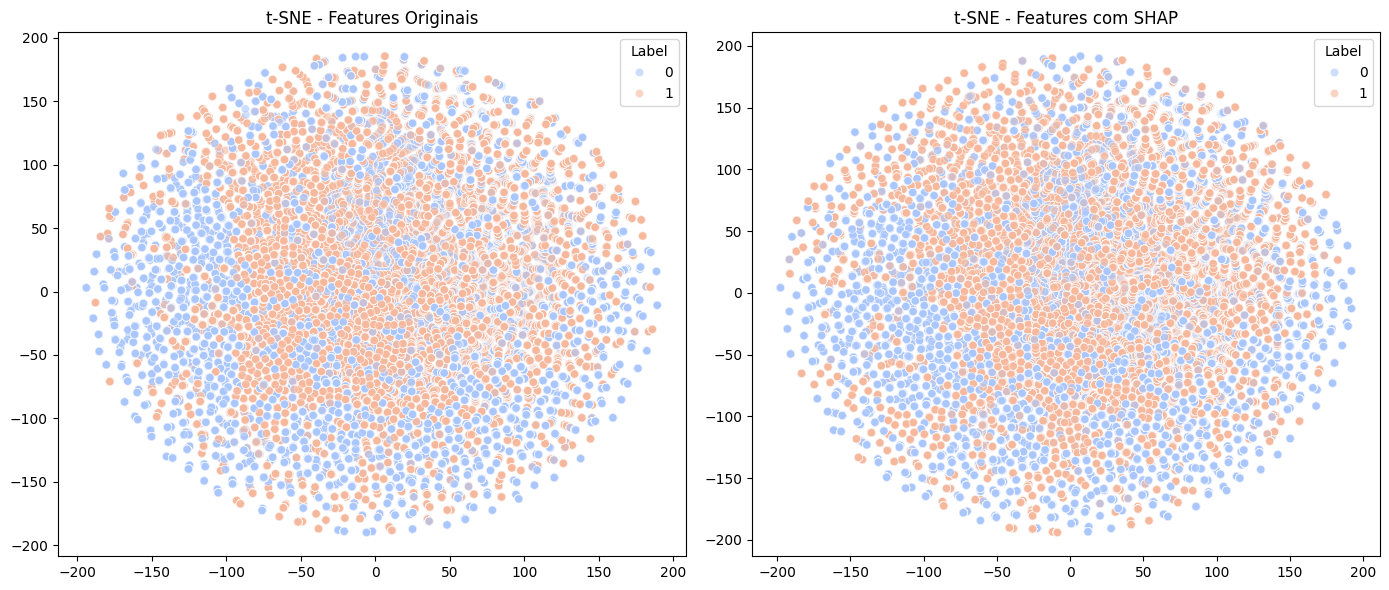

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=X_tsne_orig[:, 0], y=X_tsne_orig[:, 1], hue=y, palette="coolwarm", alpha=0.6, ax=axes[0])
axes[0].set_title("t-SNE - Features Originais")
axes[0].legend(title="Label", loc="best")

sns.scatterplot(x=X_tsne_shap[:, 0], y=X_tsne_shap[:, 1], hue=y, palette="coolwarm", alpha=0.6, ax=axes[1])
axes[1].set_title("t-SNE - Features com SHAP")
axes[1].legend(title="Label", loc="best")

plt.tight_layout()
plt.show()


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_shap, y, test_size=0.2, stratify=y, random_state=42
)

In [30]:
model = LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=64, random_state=42)
model.fit(X_train, y_train)


LGBMClassifier(learning_rate=0.05, n_estimators=200, num_leaves=64,
               random_state=42)

In [31]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("📊 MÉTRICAS DE AVALIAÇÃO")
print(f"Acurácia:  {acc:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\nMatriz de Confusão:")
print(cm)

# Exibe também o relatório completo
print("\nRelatório completo:")
print(classification_report(y_test, y_pred, digits=4))


📊 MÉTRICAS DE AVALIAÇÃO
Acurácia:  0.7863
Precisão:  0.7808
Recall:    0.8474
F1-Score:  0.8128

Matriz de Confusão:
[[5240 2114]
 [1356 7531]]

Relatório completo:
              precision    recall  f1-score   support

         0.0     0.7944    0.7125    0.7513      7354
         1.0     0.7808    0.8474    0.8128      8887

    accuracy                         0.7863     16241
   macro avg     0.7876    0.7800    0.7820     16241
weighted avg     0.7870    0.7863    0.7849     16241

